In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path("/Users/syedadnanahmad/Downloads/AI_TUMOUR_detection")
EMB_ROOT     = PROJECT_ROOT / "embeddings"
IDX_CSV      = PROJECT_ROOT / "notebooks" / "slide_index.csv"
MODEL_PATH   = PROJECT_ROOT / "models" / "oscc_topkK20_best.pth"

df_index = pd.read_csv(IDX_CSV)
OSCC_CLASSES = ["wdoscc","mdoscc","pdoscc"]

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"

print("Device:", device)


Device: mps


In [2]:
import torch.nn as nn

class TopK_AttentionMIL(nn.Module):
    def __init__(self, emb_dim=512, hidden_dim=512, num_classes=3, k=20):
        super().__init__()
        self.k = k
        self.V = nn.Linear(emb_dim, hidden_dim)
        self.U = nn.Linear(emb_dim, hidden_dim)
        self.w = nn.Linear(hidden_dim, 1)

        # IMPORTANT: dropout enabled for MC Dropout
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim//2),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(emb_dim//2, num_classes)
        )

    def forward(self, H):
        Vh = torch.tanh(self.V(H))
        Uh = torch.sigmoid(self.U(H))
        A  = self.w(Vh * Uh).squeeze(1)
        k = min(self.k, H.shape[0])
        top_vals, top_idx = torch.topk(A, k)
        H_top = H[top_idx]
        A_top = torch.softmax(top_vals, dim=0)
        agg = torch.sum(A_top.unsqueeze(1) * H_top, dim=0)
        logits = self.classifier(agg)
        return logits.unsqueeze(0)

# Load model
model = TopK_AttentionMIL().to(device)
ck = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(ck["model_state"])
model.train()  # IMPORTANT: keep dropout active


TopK_AttentionMIL(
  (V): Linear(in_features=512, out_features=512, bias=True)
  (U): Linear(in_features=512, out_features=512, bias=True)
  (w): Linear(in_features=512, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=3, bias=True)
  )
)

In [5]:
def mc_dropout_predict(emb, T=20):
    """Run T stochastic forward passes with dropout active.
    emb: torch.Tensor of shape (K, D) on the device
    returns: mean_p (1D numpy array length C), var_p (1D), entropy (float), preds (T x C numpy array)
    """
    preds = []
    for _ in range(T):
        logits = model(emb)                # logits shape: (1, C)
        p = F.softmax(logits, dim=1)      # keep as (1, C)
        preds.append(p.detach().cpu().numpy()[0])  # append 1D prob vector length C
    preds = np.vstack(preds)              # shape (T, C)
    mean_p = preds.mean(axis=0)
    var_p  = preds.var(axis=0)
    ent = -np.sum(mean_p * np.log(mean_p + 1e-8))
    return mean_p, var_p, ent, preds


In [6]:
rows = []
test_df = df_index[(df_index["split"]=="test") & (df_index["class"].isin(OSCC_CLASSES))]

for _, r in test_df.iterrows():
    slide = r["slide_id"]; cls = r["class"]
    emb_path = EMB_ROOT / "test" / cls / f"{slide}.npy"
    emb = np.load(emb_path).astype(np.float32)

    # Top-K sampling
    idx = np.random.choice(emb.shape[0], 20, replace=(emb.shape[0] < 20))
    emb_k = torch.from_numpy(emb[idx]).to(device)

    mean_p, var_p, entropy, preds = mc_dropout_predict(emb_k, T=20)

    rows.append({
        "slide_id": slide,
        "true": cls,
        "pred": OSCC_CLASSES[np.argmax(mean_p)],
        "entropy": entropy,
        "max_confidence": float(mean_p.max()),
        "var_mean": float(var_p.mean()),
        "probs": mean_p.tolist()
    })

df_unc = pd.DataFrame(rows)
df_unc.to_csv(PROJECT_ROOT/"results"/"uncertainty_stage2.csv", index=False)

df_unc.head()


,slide_id,true,pred,entropy,max_confidence,var_mean,probs
0,o-3-00-01,mdoscc,mdoscc,1.091417,0.389408,0.000522,"[0.3147914409637451, 0.3894082009792328, 0.295..."
1,o-3-00-02,mdoscc,wdoscc,1.039807,0.433844,0.000582,"[0.4338439404964447, 0.38427647948265076, 0.18..."
2,o-3-00-03,mdoscc,wdoscc,1.057834,0.410346,0.000595,"[0.4103458523750305, 0.38474756479263306, 0.20..."
3,o-3-00-04,mdoscc,pdoscc,1.090181,0.376360,0.000409,"[0.27504411339759827, 0.34859633445739746, 0.3..."
4,o-3-00-05,mdoscc,mdoscc,1.087569,0.397298,0.000494,"[0.3264526426792145, 0.3972982168197632, 0.276..."


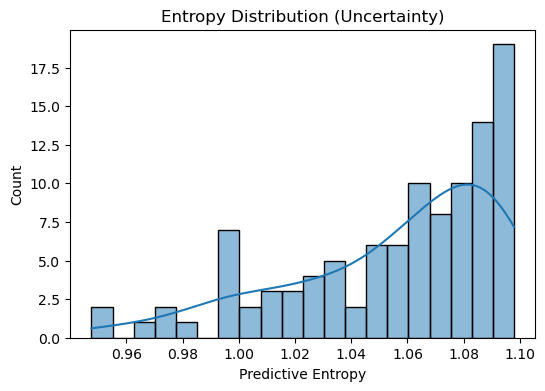

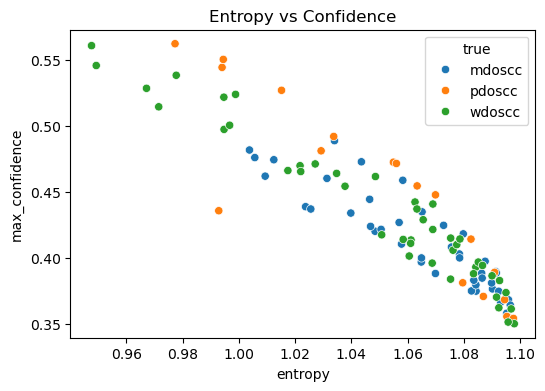

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df_unc["entropy"], bins=20, kde=True)
plt.title("Entropy Distribution (Uncertainty)")
plt.xlabel("Predictive Entropy")
plt.savefig(PROJECT_ROOT/"results"/"uncertainty_entropy_hist.png")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df_unc, x="entropy", y="max_confidence", hue="true")
plt.title("Entropy vs Confidence")
plt.savefig(PROJECT_ROOT/"results"/"uncertainty_entropy_vs_confidence.png")
plt.show()
